<a href="https://colab.research.google.com/github/manuelagutierrezss16/Integraci-n-de-Datos-y-Prospectiva/blob/main/Copia_de_1_TENDENCIA_CENTRAL_Y_DISPERSI%C3%93N_CLASE_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de Estudio**



* EVERGREEN es un conglomerado taiwanés que
opera en diversas industrias a nivel global. Su principal empresa, Evergreen Marine Corporation, se especializa en el transporte marítimo de contenedores, gestionando una flota de más de 150 buques y ofreciendo servicios en 240 puertos alrededor del mundo.
La empresa, está interesada en desarrollar un sistema por adaptación y aprendizaje que le permita proyectar desde la gestión de sus riesgos el valor potencial de captura de gases de efecto invernadero



Las variables que serán utilizadas para este proceso son las siguientes:
*   Frecuencua: Indica el numero de contenedores semanales que la empresa deja en tierra (numero/semana).
*   Severidad: es el costo promedio del tratamiento de cada contenedor en tierra (USD/contenedor).
*   Distribucion perdidas: Es el producto entre la Frecuencia y la Severidad. Esta distribución agrupa los parametros de riesgo.

**Metodo medidad tendencia y disperción**
Se preocedera con






### 0. Instalación y carga de librerías de trabajo

In [ ]:
import numpy as np
import pandas as pd #Leer archivos
import matplotlib.pyplot as plt #Graficar
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # los warningss existen porque la tabla no es del mismo tamaño toda

#Para cargar datos de forma automatica
from google.colab import files, drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Carga de los datos de trabajo


Este es el histograma para la Frecuencia


,LI,LS,ND,fi,MC
0,4.0,12.2,784.0,0.279601,8.1
1,12.2,20.4,575.0,0.205064,16.3
2,20.4,28.6,492.0,0.175464,24.5
3,28.6,36.8,369.0,0.131598,32.7
4,36.8,45.0,295.0,0.105207,40.9
5,45.0,53.2,216.0,0.077033,49.1
6,53.2,61.4,46.0,0.016405,57.3
7,61.4,69.6,18.0,0.006419,65.5
8,69.6,77.8,6.0,0.002140,73.7
9,77.8,86.0,3.0,0.001070,81.9


Este es el histograma para la Severidad


,LI,LS,ND,fi,MC
0,0.396153,9.854509,1942.0,0.692582,5.125331
1,9.854509,19.312865,534.0,0.190442,14.583687
2,19.312865,28.771222,153.0,0.054565,24.042044
3,28.771222,38.229578,71.0,0.025321,33.500400
4,38.229578,47.687934,60.0,0.021398,42.958756
5,47.687934,57.146291,26.0,0.009272,52.417113
6,57.146291,66.604647,10.0,0.003566,61.875469
7,66.604647,76.063003,2.0,0.000713,71.333825
8,76.063003,85.521360,2.0,0.000713,80.792181
9,85.521360,94.979716,4.0,0.001427,90.250538


Este es el histograma para la LDA


,LI,LS,ND,fi,MC
0,2.599197,308.929450,2209.0,0.787803,155.764324
1,308.929450,615.259703,356.0,0.126961,462.094577
2,615.259703,921.589957,116.0,0.041369,768.424830
3,921.589957,1227.920210,46.0,0.016405,1074.755083
4,1227.920210,1534.250463,27.0,0.009629,1381.085337
5,1534.250463,1840.580717,18.0,0.006419,1687.415590
6,1840.580717,2146.910970,20.0,0.007133,1993.745843
7,2146.910970,2453.241223,7.0,0.002496,2300.076097
8,2453.241223,2759.571476,4.0,0.001427,2606.406350
9,2759.571476,3065.901730,1.0,0.000357,2912.736603


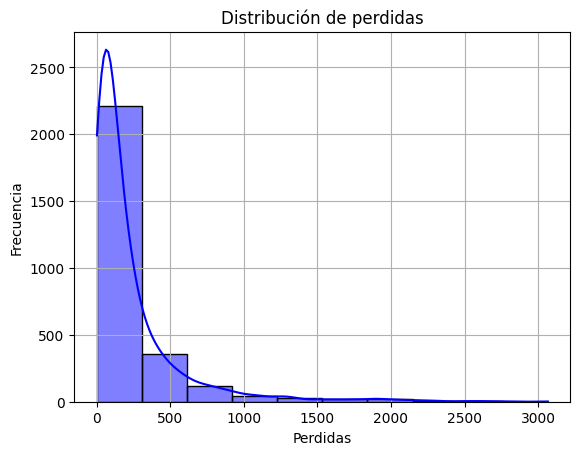

In [ ]:
df="/content/1. RiesgoOperacional_EVERGREEEN.xlsx"
XDB= pd.read_excel(df,sheet_name=0)

# la base de datos ya no solo tiene datos sino unas formulas extra, por esto solo tomamos los datos que necesitamos
# Usamos .iloc para jalar las variables que quiero usar
Freq=XDB.iloc[:,3] # := todas las filas ; 3= columna
Sev=XDB.iloc[:,4]
LDA= Freq*Sev

# Se grafica
plt.figure()
sns.histplot(LDA,color='blue',bins=10,kde=True)
plt.title('Distribución de perdidas')
plt.xlabel('Perdidas')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()




### 2. Construcción del histograma de frecuencias

In [ ]:

# Sacamos el NUMERO DE INTERVALOS
 NI=10 ESTE SE CAMBIA SE PONE AL DEFINIR DEF Y EN LAS MEDIDAS AL ESPECIFICARSE

# Agrupamos los datos en ese NI, con este tipo de librerías se puede dar los datos del histograma en las variables
  counts,Limits=np.histogram(LDA,bins=NI)
# para verlo selecciono la parte de la variable count/Limits y CTRL+Shift+Enter
  LI=Limits[:-1] #Limites inferiores
  LS=Limits[1:] #Limites superiores (despues del 1)
  fi=counts/sum(counts) #frecuencia relativa o porcentaje de datos por intervalo
  MC=(LI+LS)/2 #Marca de clase: dato representativo de cadqa intervalo

  df1= pd.DataFrame(np.column_stack((LI,LS,counts,fi,MC))) #Pd.dataframe (modo tabla), np.column (organizado en columnas)
  df1.columns=["LI","LS","ND","fi","MC"] #ND es numéro de datos
  display(df1)


### 3. Medidas de tendencia central

In [ ]:
#1 Media: Valor esperado de una pérdida (¿Qué es lo más común que pase?)
u= np.sum(MC*fi)
print("La media es: ",u)

#2 Varianza: Indica que tan dispersos están los datos al reddedor de la Media
varc=np.sum(((MC-u)**2)*fi)
print("la varianza es:", varc)

#3 La desviación: raiz cuadrada de la varianza
sigma=np.sqrt(varc)
print("la desviación es: ", sigma)

#4 Intervalo de variación de las perdidas
print("El límite inferior es:", u-2*sigma) # se multiplica *2 por el intervalo de confianza, en 2 sigmas se encuentra el 95% de los datos,
print("El liite superior es:", u+2*sigma)#  si solo fuera 1 se encuentra el 68% de los datos

#5 coeficiente de asimetria
cas=np.sum(((MC-u)**3)*fi)/((sigma**3))
print("El coeficiente de asimetría es:", cas)

#6 coeficiente de curtosis


La media es:  231.63677747473713
la varianza es: 115372.65520653517
la desviación es:  339.66550488169264
El límite inferior es: -447.69423228864815
El liite superior es: 910.9677872381224
El coeficiente de asimetría es: 3.385655388492144
